In [1]:
import torch
from sorl.gat_sim import GAT, GATConfig, BOS_TOKEN_ID
torch.set_float32_matmul_precision('high')  # Enable TF32 for ~2x speedup
# For fast training, set 'BOS_TOKEN_ID' to 15 in 'sorl/gat_sim.py' 

gat_config = GATConfig(
    vocab_sizes=[BOS_TOKEN_ID+1, 6],  # 6 abstract tokens
    n_layer=4,
    n_head=4,
    n_embd=128,
    device="cuda" if torch.cuda.is_available() else "cpu"
)
    
model = GAT(gat_config)
# model = model.to("cuda")
# model = torch.compile(model)

In [2]:
# ---- Copy & Paste Data Loader ----
from data.copy_paste import CopyPasteDataLoader

seq_len = 4
loader = CopyPasteDataLoader(vocab_size=16, max_token=10, seq_len=seq_len, device='cpu')
tokens, loss_mask = loader.get_batch(2)

$\textbf{Experiment}$ 1.
- temperature=1.0, seq_len=1, memory_span=4 | acc: 100% | traj loss: 0.02 | abs loss: 0.01 | search adv: 90% | # abs utilized: 1 | utilized rate: 16%
- temperature=1.0, seq_len=1, memory_span=1 | acc: 100% | traj loss: 0.02 | abs loss: 0.01 | search adv: 90% | # abs utilized: 1 | utilized rate: 16%
- temperature=5.0, seq_len=1, memory span=1 | acc: 100% | traj loss: 0.01 | abs loss: 0.01 | search adv: 90% | # abs utilized: 3 | utilized rate: 50% 
- temperature=10.0, seq_len=1, memory span=1 | acc: 100% | traj loss: 0.02 | abs loss: 0.01 | search adv: 90% | # abs utilized: 2 | utilized rate: 33% 
- temperature=10.0, seq_len=1, memory span=1 | acc: 100% | traj loss: 0.01 | abs loss: 0.01 | search adv: 90% | # abs utilized: 4 | utilized rate: 67% 

- temperature=10.0 seq_len=4 memory_span=10 K=1 | acc: 100% | traj loss: 0.82 | abs loss: 0.01 | search adv: 80% | # abs utilized: 1 | utilized rate: 16% 
- temperature=10.0 seq_len 4 memory_span 10 K 4 | acc: 0% | traj loss: 1.86 | abs loss 0.26 | search adv: 5.42% | # abs utilized: 3 | utilized rate: 33%
- temperature=10.0 seq len 4 memory span 10 K 2 | acc: 0% | traj loss: 1.81 | abs loss 0.02 | search adv: 23% | # abs utilized: 1 | utilized rate: 16% 
- temperature=5.0 seq len 4 memory span 10 K 2 | acc: 0% | traj loss: 1.78 | abs loss 0.02 | search adv: 47% | # abs utilized: 1 | utilized rate: 16% 
- temperature=5.0 seq len 4 memory span 1 K 2 | acc: 0% | traj loss: 1.82 | abs loss: 0.02 | search adv: 43% | # abs utilized: 1 | utilized rate: 16%

- (GPT) (BTW it's equivalent to using SoRL with $K = \infty$) seq len 4 memory span 1 | traj loss: 1.82
- (GPT) (BTW it's equivalent to using SoRL with $K = \infty$) seq len 4 memory span 10 | traj loss: 0.84 | acc: 100%

- temperature=5.0 | seq len 4 memory span 10 K 4 | traj objective only | acc: 100% | traj loss: 1.06 | abs loss: 8.21 | search adv: 4.3% | # abs utilized: 5 | utilize rate: 83.3%

- temperature=5.0 | seq len 4 memory span 10 -> 1 K 4 | acc 0% | traj loss 2.3 | abs loss 0.01 | search adv: 23% | # abs utilized: 1 | utilize rate: 16%

- SoRL + GAPT | 200 epochs | temperature 5.0 seq len 4 memory span 10 K 4 | acc 18% | traj loss 1.54 | abs loss 0.39 | search adv: 8% | # abs utilized: 2 | utilization rate: 33%
- SoRL + GAPT | 400 epochs | temperature 5.0 seq len 4 memory span 10 K 4 | acc 100% | traj loss 0.99 | abs loss 0.01 | search adv: 22% | # abs utilized: 1 | utilization rate: 16%
- SoRL + GAPT | 300 epochs | temperature 5.0 seq len 4 memory span 10->1 K 4 | acc 0% | traj loss 1.80 | acc 0% | ...  
- SoRL + GAPT | 300 (memory span 10 -> 4) + 200 (memory span 10 -> 4) | temperature 5.0 seq len 4 K 4 | traj loss 1.05 | acc 100% | abs loss 0.57 | search adv: 40% | # abs utilized: 1 | utilization rate: 16%
- SoRL + GAPT | 400 epochs | temperature 5.0 seq len 4 K 4 memory span 10 -> 4 | traj loss 1.0 | acc 100% | abs loss 0.01 | search adv: 32% | # abs utilized 1

$\textbf{Analysis 1}$. A failure mode here, is the model would repeatitively predict the same number no matter what. I do wonder how is it possible that we are able to get 'advantage' despite having 0 accuracy here? Also what about the baseline performance in this case? Can a naive transformer nails copy & paste? 



$\textbf{Reflection 1}$. 
- This is starting to make sense, with greedy rollout retained, using a high temperature is actually just brodening the horizon, it's actually more beneficial than a low temperature rollout, as later is very similar to greedy rollout and therefore risks collapsing the vocabulary. So, higher temperature helps increase the vocabulary utilization rate. But intuitively, it feels like there should be an 'optimal utilization rate' of sorts --- yet trajectory perplexity should surely be the most important target here. 



1. Different $\lambda$ values for adding $l_{\text{traj}} +  \lambda l_{\text{abs}}$. 

$\textit{Question 1}$. As model converge, same temperature gives stochastic rollouts that looks more and more similar to the greedy one, how do we avoid collapsing rollouts and make it possible for model to explore bigger abstract vocabulary? This is important for composition. 

$\textit{Idea 1}$. Entropy regularization on abstraction can improve the 'utilization rate'. Just wish to see what'd happen if we encourage this form of exploration -- will we get better result or ends up getting worse result, or even the same result somehow? 

$\textbf{Experiment 2}$. 
- (a). 300 iterations | GAPT + SoRL | temp=5.0 | alpha =2.0 | memory span 10 -> 4 | traj_loss: 1.01 | abs_loss: 1.14 | abs_entropy: 1.51 | search adv: 9.71% | util number 1
- (b). 300 iterations | GAPT + SoRL | temp=5.0 | mute abs_loss, use alpha=2.0 | memory span 10 -> 4 | traj_loss: 1.01 | abs_loss: 8.77 | abs_entropy: 1.61 | search adv: 4.61% | util number 1
- (c). 300 iterations | GAPT + SoRL | temp=10.0 | alpha =2.0 | memory span 10 -> 4 | traj_loss: 1.04 | abs_loss: 0.95 | abs_entropy: 1.49 | search adv: 24.77% | util number 1
- (d). 300 iterations | GAPT + SoRL | temp=10.0 | alpha=2.0 | memory span 10 -> 4 | max_iterations 2 | # util 1
- (e). 300 iterations | SoRL | alpha=2.0 | max iteration 2 | acc: 85% | traj_loss: 1.10 | abs_loss: 2.79 | abs_entropy: 0.64 | search adv: -1.83% | # util 1
- (f). 300 iteartions | SoRL v2 | alpha= - 2.0 | max iteration 2 | acc: 100% | traj_loss: 1.04 | abs_loss: 1.98 | abs_entropy: 0.31 | search adv: 19.11% | # util 1
- (g). 300 iteartions | SoRL v2 | alpha= 2.0 | max iteration 2 | acc: 100% |  traj_loss: 1.03 | abs_loss: 1.56 | abs_entropy: 1.58 | search adv: 2.76% | # util 1
- (h). 300 iterations | SoRL v2 | alpha=0.0 | max iteration 2 | acc: 100% | traj_loss: 1.01 | abs_loss: 1.38 | abs_entropy: 1.51 | search adv: 29.05% | # util 2
- (i). 300 iterations | SoRL v2 | alpha=0.0 | max iteration 1 | acc: 95% | traj_loss: 1.04 | abs_loss: 1.71 | abs_entropy: 1.52 | search adv: 32.12% (extremely unstable) | # util 4
- (i2). 300 iterations | SoRL v2 | alpha=0.0 | max iteration 1 | acc: 100% | traj_loss: 1.03 | abs_loss: 1.54 | abs_entropy: 1.59 | search adv: 0.44% | # util 2
- (j). 300 iterations | SoRL | alpha=0.0 | max iteration 1 | acc: 40% | traj_loss: 1.23 | abs_loss: 0.01 | abs_entropy: 0.03 | search adv: 46.98% | # util 1
- (k). 300 iterations | SoRL | alpha=0.0 | max iteration 2 | acc: 100% | traj_loss: 1.01 | abs_loss: 0.00 | abs_entropy: 0.01 | search adv: 56.30% | # util 1
- (l). 300 iterations | SoRL | alpha=0.0 | max iteration 3 | acc: 100% | traj_loss: 1.02 | abs_loss: 0.00 | abs_entropy: 0.02 | search adv: 45.23% | # util 1
- (m). 300 iterations | SoRL v2 | alpha=0.0 | max iteration 3 | acc: 100% | traj_loss: 1.02 | abs_loss: 1.41 | abs_entropy: 1.50 | search adv: 17.85% | # util 1


$\textit{Observation 1}$. It appears that entropy regularization term can replace GAPT?
- Nope, it's more likely that with fixed errors etc, we don't need GAPT gadget to close the gap in 4-digit copy & paste task. The entropy regularization term itself doesn't really help here. 

1. SoRL stabilizes abstraction compared to SoRL v2, but SoRL hurts traj perplexity --- why does a stable abstraction hurts traj perplexity? Because it doesn't fully utilize abstraction's benefits? 
2. max_iteration=2 stabilizes abstraction compared to max_iteration=1, while slightly improve traj_perplexity. Comparing (k) & (j) or (h) & (i) reveals the power of having max_iteration=2 here. 


$\textbf{Experiment 3}$. 
- Let's try to ensure we have big vocab_utilization rate. I made the choice of including greedy-rollout to stabilize the chosen abstraction, but now it feels like it collapse the vocabulary. This resurrects the idea of GRPO perhaps? GRPO -- SoRL v2 (no greedy retension) -- SoRL (greedy retention), it seems that SoRL leads to vocabulary collapse, whilst SoRL v2 weaken such behavior and GRPO is likely better in terms of vocab utilization (not sure). 


$\textit{Trick 1}$. Weighted Loss for each token. 
- 1. Encourage bigger advantage in trajectory perplexity
- 2. Encourage rarely used abstraction

In [3]:
from sorl.neo_utils import sorl_search, sorl_search_v2, compute_loss, sorl_evaluate, compute_vocab_utilization_rate
from sorl.gapt import GatedPhaseTransition

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.1)

batch_size = 16
# memory_span = 1
memory_span = 2 * seq_len + 2
attn_blocksize = 1792
K = 4
n = 4
# assert seq_len % K == 0, f"seq_len {seq_len} must be divisible by K {K}"
max_iterations = 2
temperature = 10.0
alpha = 0.0
num_steps = 300
gapt = GatedPhaseTransition()

for step in range(num_steps): 
    memory_span = seq_len + int((1 - step / num_steps) * (2 * seq_len + 2 - 1))
    # print(f"step {step} | memory_span: {memory_span}")
 
    optimizer.zero_grad()

    tokens, _ = loader.get_batch(batch_size)

    # --- mixture of SoRL selection & deep supervision (avg. loss per iteration) ---
    with torch.no_grad(): 
        search_tokens, search_ppt, search_adv, pt_curiosity = sorl_search_v2(tokens, model, n=n, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperature,
                                                               truncate_seq_len=False)
    
    # --- compute loss ---
    traj_loss, abs_loss = compute_loss(search_tokens, model, memory_span=memory_span, attn_blocksize=attn_blocksize,
                                       per_pos_curiosity=pt_curiosity)
                                       
    loss = gapt.step(traj_loss, abs_loss, verbose=True)
    # loss = traj_loss + abs_loss

    # --- optimize --- 
    loss.backward() 
    optimizer.step()

    if step % 2 == 0: 
        with torch.no_grad(): 
            val_tokens, val_adv, traj_loss, abs_loss = sorl_evaluate(search_tokens, model, n=4, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=10.0,
                                                                   truncate_seq_len=False)
            traj_loss, abs_loss = compute_loss(search_tokens, model, memory_span=memory_span, attn_blocksize=attn_blocksize)
            compute_vocab_utilization_rate(val_tokens, model)
        print(f"validation step {step} | traj_loss: {traj_loss.item():.2f} | abs_loss: {abs_loss.item():.2f} | search adv: {val_adv.item() * 100:.2f}% | curiosity std: {pt_curiosity.std().item():.2f}")

validation step 0 | traj_loss: 3.03 | abs_loss: 3.11 | search adv: 0.01% | curiosity std: 0.02
validation step 2 | traj_loss: 2.95 | abs_loss: 3.22 | search adv: -0.05% | curiosity std: 0.02
validation step 4 | traj_loss: 2.76 | abs_loss: 3.46 | search adv: -0.10% | curiosity std: 0.02
validation step 6 | traj_loss: 2.64 | abs_loss: 3.76 | search adv: -0.01% | curiosity std: 0.02
validation step 8 | traj_loss: 2.52 | abs_loss: 4.07 | search adv: -0.07% | curiosity std: 0.02
validation step 10 | traj_loss: 2.47 | abs_loss: 4.38 | search adv: -0.01% | curiosity std: 0.02
validation step 12 | traj_loss: 2.42 | abs_loss: 4.69 | search adv: -0.03% | curiosity std: 0.02
validation step 14 | traj_loss: 2.35 | abs_loss: 4.98 | search adv: 0.02% | curiosity std: 0.02
validation step 16 | traj_loss: 2.37 | abs_loss: 5.24 | search adv: 0.01% | curiosity std: 0.02
validation step 18 | traj_loss: 2.34 | abs_loss: 5.49 | search adv: 0.03% | curiosity std: 0.02
validation step 20 | traj_loss: 2.35 | 

1. Basline | abs util rate 33% | 3.6% search adv | 100% acc | abs loss: 1.31
2. abs_curiosity --> abs util rate 50% (validation sequence) | 100% acc
3. abs_curiosity.pow(3) --> abs util rate 16% | 25% search adv | 100% acc | abs loss: 1.43 
4. perplexity_advantage | abs util rate 16% | 5% search adv | 100% acc | abs loss: 1.72 | traj adv std: 0.36
5. perplexity advatage + abs_curiosity | abs util rate 50% | 70% acc | -500% search adv | abs loss: 1.65  
6. SoRL (greedy retention) + perplexity advantage & abs_curiosity gives 10% acc | 40% search adv | this demonstrates the greedy retended ver. of SoRL is worse than non-greedy retended ver. 
7. SoRL (greedy retention) + abs_curiosity | 10% acc | 18% search adv | 16% vocab util | abs loss 0.0 | again this demonstrates greedy retended ver. of SoRL is worse than non-greedy retended ver. 
8. abs curiosity | abs util rate 50% | 100% acc | 0.4% search adv | 33% vocab util | abs loss 1.53
9. abs curiosity.pow(1.5) | abs util rate 33% | 100% acc | 21% search adv | abs loss: 1.39 
10. abs curiosity.pow(0.5) |  abs util rate 16% | 100% acc | 0.3% search adv | abs loss: 1.58
11. temperature 1.0 (prev 10.0) | abs util rate 16% | 100% acc | 10% search adv | abs loss: 0.65
12. temperature 10.0 | abs util rate 50% | 100% acc | 10% search adv | abs loss 1.30 


In [6]:
# generate function implementation 
# ----------------------------------
from sorl.neo_utils import generate

tokens, loss_mask = loader.get_batch(1)
idx = tokens[:, :1 + seq_len].clone()
print(f"init   | idx: {idx[0].tolist()}")
for i in range(seq_len): 
    idx = generate(model, idx, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=1792, temperature=0.0)
    idx_without_abstraction = idx[idx < model.vocab_sizes[0]]
    print(f"step {i+1} idx (abstraction free): {idx_without_abstraction.tolist()}")
    print(f"                         idx : {idx[0].tolist()}")

correct_cp = torch.allclose(idx_without_abstraction[1 : 1 + seq_len], idx_without_abstraction[1 + seq_len : 2 + 2*seq_len])
print(f"Copy correct: {correct_cp}")

init   | idx: [15, 9, 1, 5, 8]
step 1 idx (abstraction free): [15, 9, 1, 5, 8, 9]
                         idx : [15, 9, 1, 5, 8, 17, 9]
step 2 idx (abstraction free): [15, 9, 1, 5, 8, 9, 1]
                         idx : [15, 9, 1, 5, 8, 17, 9, 1]
step 3 idx (abstraction free): [15, 9, 1, 5, 8, 9, 1, 5]
                         idx : [15, 9, 1, 5, 8, 17, 9, 1, 5]
step 4 idx (abstraction free): [15, 9, 1, 5, 8, 9, 1, 5, 8]
                         idx : [15, 9, 1, 5, 8, 17, 9, 1, 5, 8]
Copy correct: True


In [8]:
from sorl.eval import compute_vocab_utilization_rate

def eval_cp(model, tokens, K, max_iterations, memory_span, seq_len, loader, temperature=0.0, num_samples=100):
    n_correct = 0
    abs_idx = []
    for _ in range(num_samples): 
        tokens, loss_mask = loader.get_batch(1)
        idx = tokens[:, :1 + seq_len].clone()
        for i in range(seq_len): 
            idx = generate(model, idx, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=1792, temperature=temperature)
            idx_without_abstraction = idx[idx < model.vocab_sizes[0]]
            abs_idx.append(idx[idx >= model.vocab_sizes[0]])
        correct_cp = torch.allclose(idx_without_abstraction[1 : 1 + seq_len], idx_without_abstraction[1 + seq_len : 2 + 2*seq_len])
        n_correct += correct_cp
    acc = n_correct / num_samples
    print(f"=== Copy & Paste Evaluation ===\n Copy correct: {acc * 100:.2f}%")

    data = torch.cat(abs_idx, dim=0)
    abs_util_rate = compute_vocab_utilization_rate(data, model)
    return acc, abs_util_rate


eval_cp(model, tokens, K, max_iterations, memory_span, seq_len, loader, num_samples=20)

=== Copy & Paste Evaluation ===
 Copy correct: 100.00%


(1.0, 0.16666666666666666)

 Total abs tokens: 6 | Unique abs tokens: 1 | Abs util rate: 16.67%


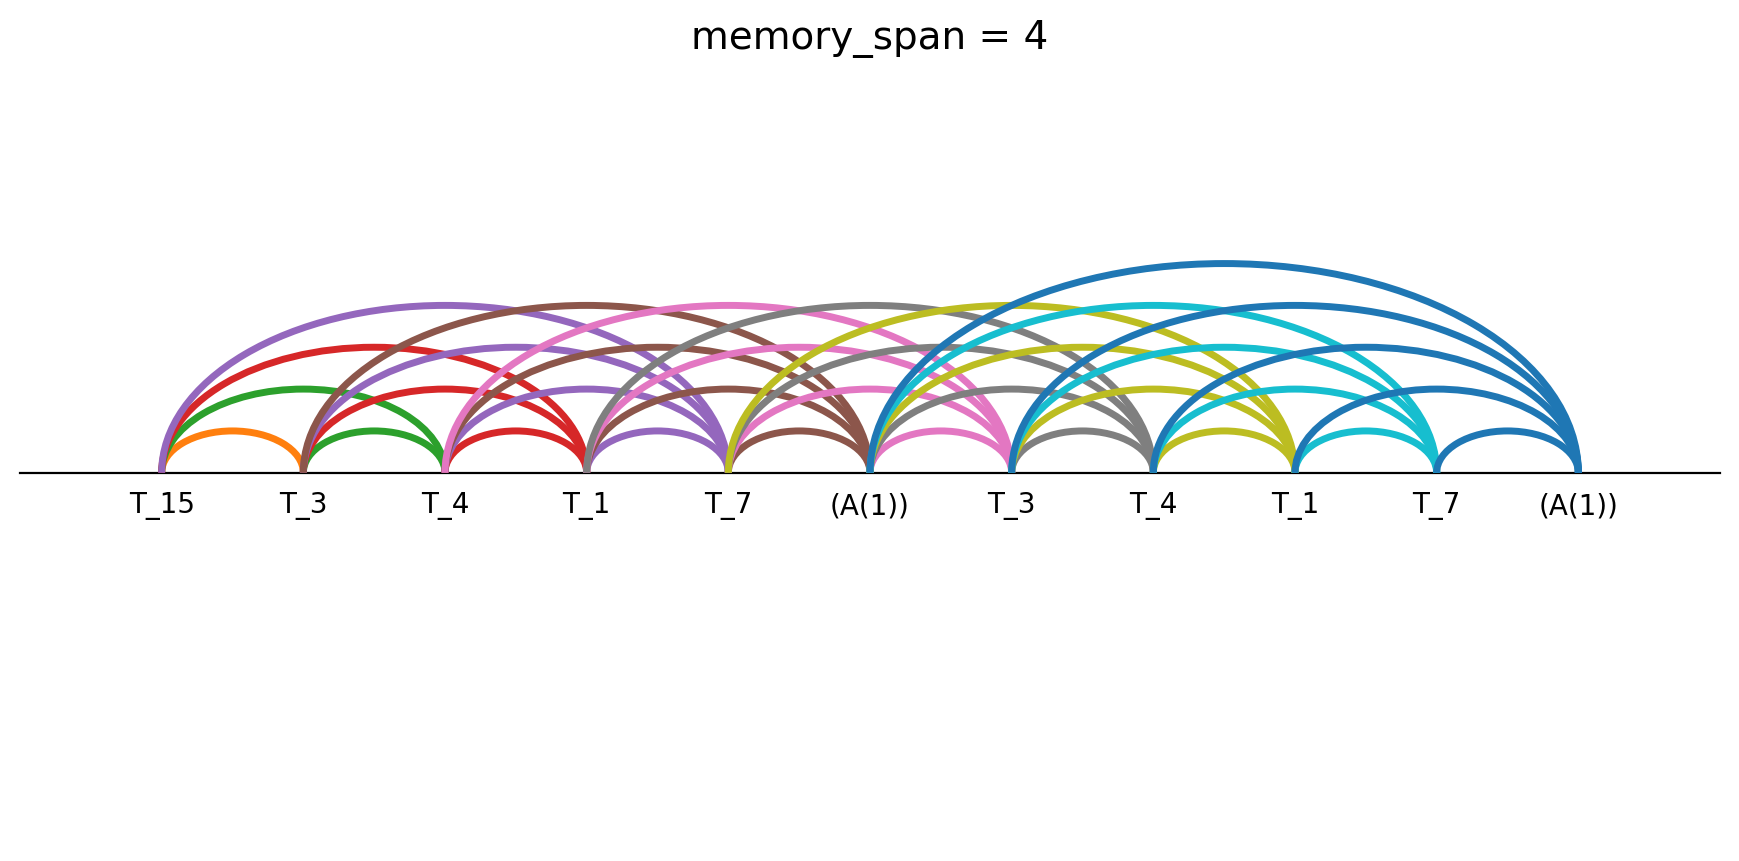

In [6]:
# Simple 2D Attention Mask (without num_heads dimension)
# ======================================================

import torch
from sorl.stat import plot_attn_arcs, materialize_attention_mask, AttentionMaskVisualizer

# Your existing variables
tokens, loss_mask = loader.get_batch(1)
with torch.no_grad(): 
    search_tokens, search_ppt, search_adv = sorl_search(tokens, model, n=n, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperature,
                                                            truncate_seq_len=False)

# Generate 2D attention mask
levels = (search_tokens >= model.vocab_sizes[0]).long()
attn_mask = materialize_attention_mask(search_tokens, model, memory_span, attn_blocksize=1792)
visualizer = AttentionMaskVisualizer(search_tokens, model, attn_mask)

visualizer.plot_arcs(title=f"memory_span = {memory_span}")


In [ ]:
# heuristic rollout
import os, glob, itertools
from pathlib import Path

# MPS specific data loader functional (single device ver.)
# --------------------------------------------
def _load_data_shard(file: Path):
    header = torch.from_file(str(file), False, 256, dtype=torch.int32) # header is 256 int32
    assert header[0] == 20240520, "magic number mismatch in the data .bin file"
    assert header[1] == 1, "unsupported version"
    num_tokens = int(header[2]) # number of tokens (claimed)
    with file.open("rb", buffering=0) as f:
        tokens = torch.empty(num_tokens, dtype=torch.uint16, pin_memory=False) # MPS requires pin_memory=False
        f.seek(256 * 4)
        nbytes = f.readinto(tokens.numpy()) # avoid bytes->array copy by @YouJiacheng
        assert nbytes == 2 * num_tokens, "number of tokens read does not match header"
    return tokens

def data_generator(filename_pattern: str, sequence_length: int, device: str): 

    filename_pattern = "data/fineweb10B/fineweb_train_*.bin"
    files = [Path(file) for file in sorted(glob.glob(filename_pattern))]
    file_iter = itertools.cycle(files)
    tokens, pos = _load_data_shard(next(file_iter)), 0
    while True: 
        # Concern 1. Doesn't this means end-of-file is never reached?
        if pos + sequence_length + 1 >= len(tokens): # not enough data left -> load a new file
            tokens, pos = _load_data_shard(next(file_iter)), 0

        idx = tokens[pos : pos + sequence_length + 1].unsqueeze(0).to(device=device, dtype=torch.int32, non_blocking=True)
        pos += sequence_length
        yield idx


data = _load_data_shard(Path("data/fineweb10B/fineweb_train_000002.bin"))

train_loader = data_generator(filename_pattern="data/fineweb10B/fineweb_train_*.bin", sequence_length=256, device="cpu")
val_loader = data_generator(filename_pattern="data/fineweb10B/fineweb_val_000000.bin", sequence_length=256, device="cpu")

In [ ]:
from sorl.neo_utils import sorl_search_v2 

n = 2
K = 8
max_iterations=2
memory_span=1792
attn_blocksize=1792
temperature=10.0 

tokens = next(train_loader)

with torch.no_grad(): 
    search_tokens, search_ppt, search_adv, pt_curiosity = sorl_search_v2(tokens, model, n=n, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperature)

In [ ]:
# --- Benchmark Speed & Memory Cost --- 
from sorl.benchmark import run_benchmark_suite
import torch 


# Prepare data - TEST WITH SMALLER SEQUENCE FIRST
tokens = next(train_loader)

# Run benchmark
results = run_benchmark_suite(
    model, 
    tokens, 
    memory_span=1024, 
    num_runs=10
)